In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [28]:
df=pd.read_excel("Algerian_forest_fires_dataset_UPDATE.xlsx")

In [29]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire
1,2,6,2012,30,73,13,4.0,55.7,2.7,7.8,0.6,2.9,0.2,not fire
2,3,6,2012,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0.1,not fire
3,4,6,2012,30,64,14,0.0,79.4,5.2,15.4,2.2,5.6,1.0,not fire
4,5,6,2012,32,60,14,0.2,77.1,6.0,17.6,1.8,6.5,0.9,not fire


In [30]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
dtype: int64

In [31]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  '],
      dtype='object')

In [32]:
df.columns=df.columns.str.strip()

In [33]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes'],
      dtype='object')

In [34]:
df["Classes"].unique()

array(['not fire   ', 'fire   ', 'not fire     ', 'not fire    '],
      dtype=object)

In [35]:
df["Classes"]=df["Classes"].str.strip()
df["Classes"].unique()

array(['not fire', 'fire'], dtype=object)

In [36]:
df.drop(columns=["day","month","year"],axis=1,inplace=True)
df

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire
1,30,73,13,4.0,55.7,2.7,7.8,0.6,2.9,0.2,not fire
2,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0.1,not fire
3,30,64,14,0.0,79.4,5.2,15.4,2.2,5.6,1.0,not fire
4,32,60,14,0.2,77.1,6.0,17.6,1.8,6.5,0.9,not fire
...,...,...,...,...,...,...,...,...,...,...,...
117,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire
118,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire
119,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
120,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  122 non-null    int64  
 1   RH           122 non-null    int64  
 2   Ws           122 non-null    int64  
 3   Rain         122 non-null    float64
 4   FFMC         122 non-null    float64
 5   DMC          122 non-null    float64
 6   DC           122 non-null    float64
 7   ISI          122 non-null    float64
 8   BUI          122 non-null    float64
 9   FWI          122 non-null    float64
 10  Classes      122 non-null    object 
dtypes: float64(7), int64(3), object(1)
memory usage: 10.6+ KB


In [38]:
df["Classes"]=np.where(df["Classes"]=="not fire",0,1)

In [39]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,0
1,30,73,13,4.0,55.7,2.7,7.8,0.6,2.9,0.2,0
2,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0.1,0
3,30,64,14,0.0,79.4,5.2,15.4,2.2,5.6,1.0,0
4,32,60,14,0.2,77.1,6.0,17.6,1.8,6.5,0.9,0


In [40]:
#Independent and dependent feature
X=df.drop("FWI",axis=1)
y=df["FWI"]

In [41]:
X

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes
0,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0
1,30,73,13,4.0,55.7,2.7,7.8,0.6,2.9,0
2,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0
3,30,64,14,0.0,79.4,5.2,15.4,2.2,5.6,0
4,32,60,14,0.2,77.1,6.0,17.6,1.8,6.5,0
...,...,...,...,...,...,...,...,...,...,...
117,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,1
118,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0
119,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0
120,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0


In [42]:
y

0      0.2
1      0.2
2      0.1
3      1.0
4      0.9
      ... 
117    6.5
118    0.0
119    0.2
120    0.7
121    0.5
Name: FWI, Length: 122, dtype: float64

In [43]:
from sklearn.model_selection import train_test_split
X_Train,X_Test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [44]:
#Feature selection using correlation
def correlation(dataset,threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [45]:
corr_features=correlation(X_Train,0.85)

In [46]:
corr_features

{'BUI', 'DC'}

In [47]:
X_Train.drop(corr_features,axis=1,inplace=True)
X_Test.drop(corr_features,axis=1,inplace=True)

In [48]:
X_Train.shape,X_Test.shape

((91, 8), (31, 8))

## Standardization

In [49]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_Train_Scaled=scaler.fit_transform(X_Train)
X_Test_Scaled=scaler.transform(X_Test)

Text(0.5, 1.0, 'X_Train After scaling')

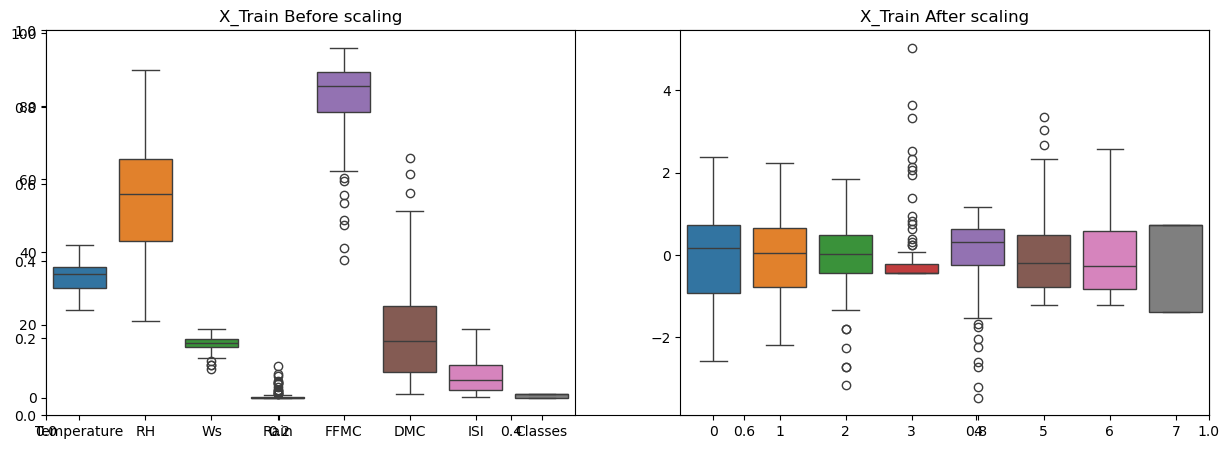

In [50]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_Train)
plt.title("X_Train Before scaling")
plt.subplot(1,2,2)
sns.boxplot(data=X_Train_Scaled)
plt.title("X_Train After scaling")

## Linear Regression Model

MSE:  1.0208049815415543
MAE:  0.7312986403618761
RMSE:  1.0103489404861838
Model Accurracy:  0.9708907435145745


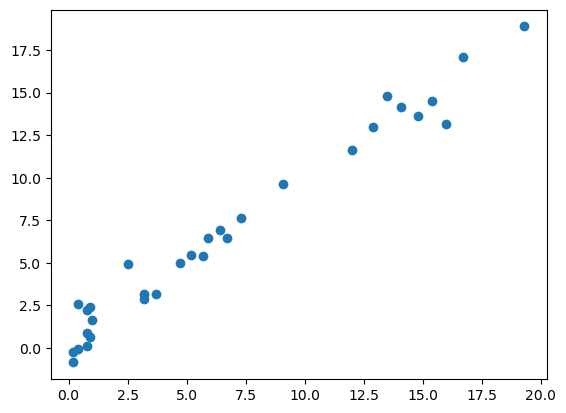

In [53]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg.fit(X_Train_Scaled,y_train)
y_pred=lin_reg.predict(X_Test_Scaled)

#Performace measure
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)

print("MSE: ",mse)
print("MAE: ",mae)
print("RMSE: ",rmse)

#Model accuracy
from sklearn.metrics import r2_score
model_accuracy=r2_score(y_test,y_pred)
print("Model Accurracy: ",model_accuracy)

plt.scatter(y_test,y_pred)

## Lasso Regression

MSE:  1.993602962453629
MAE:  1.1541788941025546
RMSE:  1.411950056642808
Model Accurracy:  0.9431504537952684


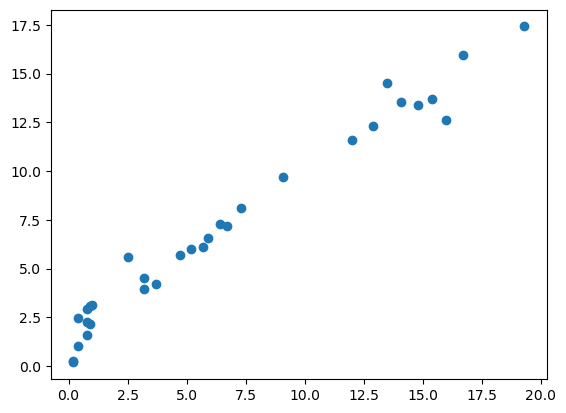

In [54]:
from sklearn.linear_model import Lasso
las_reg=Lasso()
las_reg.fit(X_Train_Scaled,y_train)
y_pred=las_reg.predict(X_Test_Scaled)

#Performace measure
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)

print("MSE: ",mse)
print("MAE: ",mae)
print("RMSE: ",rmse)

#Model accuracy
from sklearn.metrics import r2_score
model_accuracy=r2_score(y_test,y_pred)
print("Model Accurracy: ",model_accuracy)

plt.scatter(y_test,y_pred)

## Cross Validation with Lasso Regression

In [56]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_Train_Scaled,y_train)

LassoCV(cv=5)

In [57]:
y_pred=lassocv.predict(X_Test_Scaled)

MSE:  1.1480355105008657
MAE:  0.7989538368242807
RMSE:  1.0714641900226372
Model Accurracy:  0.9672626400401381


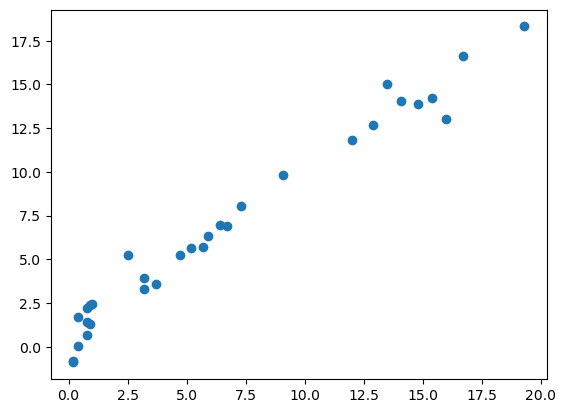

In [58]:
#Performace measure
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)

print("MSE: ",mse)
print("MAE: ",mae)
print("RMSE: ",rmse)

#Model accuracy
from sklearn.metrics import r2_score
model_accuracy=r2_score(y_test,y_pred)
print("Model Accurracy: ",model_accuracy)

plt.scatter(y_test,y_pred)

## Ridge Regression

In [59]:
from sklearn.linear_model import Ridge
ridge_regression=Ridge()
ridge_regression.fit(X_Train_Scaled,y_train)
y_pred=ridge_regression.predict(X_Test_Scaled)

from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)

print("MSE: ",mse)
print("MAE: ",mae)
print("RMSE: ",rmse)

from sklearn.metrics import r2_score
model_accuracy=r2_score(y_test,y_pred)
print("Model Accurracy: ",model_accuracy)

MSE:  1.033808172458902
MAE:  0.7451106729172158
RMSE:  1.0167635774647428
Model Accurracy:  0.9705199447563528


## ElasticNet Regression

In [60]:
from sklearn.linear_model import ElasticNet
el_regression=Ridge()
el_regression.fit(X_Train_Scaled,y_train)
y_pred=el_regression.predict(X_Test_Scaled)

In [61]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)

print("MSE: ",mse)
print("MAE: ",mae)
print("RMSE: ",rmse)

MSE:  1.033808172458902
MAE:  0.7451106729172158
RMSE:  1.0167635774647428


In [62]:
from sklearn.metrics import r2_score
model_accuracy=r2_score(y_test,y_pred)
print("Model Accurracy: ",model_accuracy)

Model Accurracy:  0.9705199447563528


## Pickle the machine learning modeals,preprocessing model Standardscaler

In [63]:
scaler

StandardScaler()

In [65]:
ridge_regression

Ridge()

In [66]:
import pickle 
pickle.dump(scaler,open("scaler.pkl","wb"))
pickle.dump(ridge_regression,open("ridge.pkl","wb"))